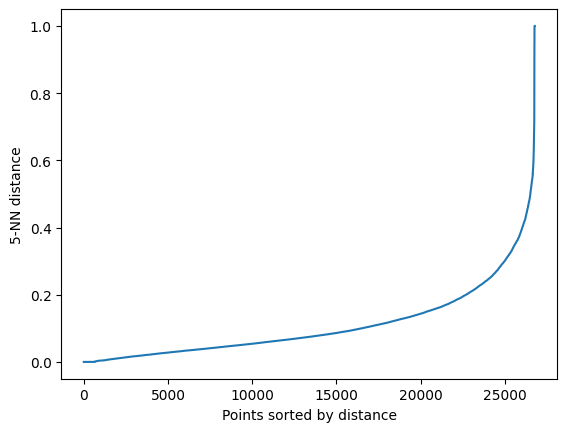

In [1]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction import DictVectorizer
from sklearn.cluster import DBSCAN
from collections import Counter
from pathlib import Path

#Epszilom paraméter kiszámítása a DBSCAN-hez
#40s alatt lefut

all_decks_df = pd.read_pickle('all_decks_df.pickle')

vectorizer = DictVectorizer(sparse=True)
X = vectorizer.fit_transform(all_decks_df["main_deck"])

k = 5

neighbors = NearestNeighbors(
    n_neighbors=k,
    metric="cosine"
)

neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)

k_distances = distances[:, k-1]
k_distances = np.sort(k_distances)

plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-NN distance")
plt.show()

In [ ]:
#Klaszterezés

dbscan = DBSCAN(
    eps=0.2,
    min_samples=5,
    metric="cosine"
)
#Az előző cella grafikonja alapján a 0.2 ideális paraméternek tűnik

labels = dbscan.fit_predict(X)

all_decks_df["cluster"] = labels

print(all_decks_df["cluster"].value_counts())

cluster
-1      3204
 14     2025
 4      1749
 9      1315
 3      1249
        ... 
 119       5
 44        5
 130       5
 31        4
 237       4
Name: count, Length: 270, dtype: int64


In [ ]:
ARCHETYPE = 4

def repr_cluster(cluster, examples=0):
    if cluster > all_decks_df["cluster"].nunique():
        print("Nincs ilyen sorszámú klaszter")
        return 0
    subframe = all_decks_df[all_decks_df["cluster"] == cluster]
    if examples:
        for deck in subframe["main_deck"].head(examples):
            print(deck)
    cluster_size = len(subframe)
    card_presence = Counter()
    for deck in subframe["main_deck"]:
        for card in deck.keys():
            card_presence[card] += 1
    for card, count in card_presence.most_common(15):
        print(card, count / cluster_size)

def get_cards(cluster, min_freq=0.05):
    if cluster > all_decks_df["cluster"].nunique():
        print("Nincs ilyen sorszámú klaszter")
        return 0
    subframe = all_decks_df[all_decks_df["cluster"] == cluster]
    cluster_size = len(subframe)
    card_presence = Counter()
    for deck in subframe["main_deck"]:
        for card in deck.keys():
            card_presence[card] += 1
    frequent_cards = []
    for card, count in card_presence.most_common():
        if count / cluster_size >= min_freq:
            frequent_cards.append(card)
    return frequent_cards
 
def write_card_set(list, name="card_set.txt"):
    with open(name, "w", encoding="utf-8") as f:
        for card in list:
            f.write(f"{card}\n")

repr_cluster(ARCHETYPE)
#14: Blue/Azorius tempo
#4: Red aggro
#9: Black midrange
#3: Bant equipment

#Ezzel elmentjük az adott klaszterre jellemző kártyák halmazát
write_card_set(get_cards(ARCHETYPE))


Mountain 0.9931389365351629
Rakdos Cackler 0.5002858776443682
Stromkirk Noble 0.45168667810177243
Pillar of Flame 0.4351057747284162
Mizzium Mortars 0.4265294453973699
Searing Spear 0.4156660949113779
Skullcrack 0.3996569468267582
Hellrider 0.389937106918239
Burning-Tree Emissary 0.36192109777015435
Boros Reckoner 0.35334476843910806
Ash Zealot 0.3304745568896512
Volcanic Strength 0.3156089193825043
Lightning Bolt 0.30417381360777584
Goblin Guide 0.27329902801600914
Lightning Mauler 0.25728987993138935


In [ ]:
#Következő lépés: átlagos/reprezentatív deck készítése egy klaszterből

#Erre megoldás: medoid - azaz olyan elem a klaszterből, ami a "legközelebb van az összes többihez"

def cosine_distance(a, b):
    #Ugyanaz a cosine távolság, amit a DBSCAN is használ
    shared = a.keys() & b.keys()
    dot = sum(a[c] * b[c] for c in shared)
    norm_a = sum(v*v for v in a.values()) ** 0.5
    norm_b = sum(v*v for v in b.values()) ** 0.5
    return 1 - dot / (norm_a * norm_b + 1e-9)


def cluster_medoid(cluster_id):
    cluster_df = all_decks_df[all_decks_df["cluster"] == cluster_id]["main_deck"].tolist()
    cluster_df = [d for d in cluster_df if sum(d.values()) == 60]
    best_idx = -1
    best_score = float("inf")
    for i, deck_i in enumerate(cluster_df):
        dist_sum = 0
        for j, deck_j in enumerate(cluster_df):
            if i == j:
                continue
            dist_sum += cosine_distance(deck_i, deck_j)
        if dist_sum < best_score:
            best_score = dist_sum
            best_idx = i
    return cluster_df[best_idx]

med_deck = cluster_medoid(ARCHETYPE)
print(med_deck)


#Pakli elmentése
DECK_DIR = Path(r"C:\Users\nagvi\AppData\Roaming\Forge\decks\constructed")

def write_deck(deck, name="Custom_deck"):
    path = DECK_DIR / f"{name}.dck"
    with open(path, "w", encoding="utf-8") as f:
        f.write("[metadata]\n")
        f.write(f"Name={name}\n")
        f.write("\n[Main]\n")
        for card, count in deck.items():
            f.write(f"{count} {card}\n")

write_deck(med_deck)


#Összerakunk és mentünk egy csupa 'alapkártyából' álló paklit is későbbi tesztelésre
rats = {'Swamp': 30, 'Rat Colony': 30}
write_deck(rats, 'enemy_deck')

{'Ghost Quarter': 1, 'Mountain': 22, "Chandra's Phoenix": 4, 'Goblin Arsonist': 1, 'Grim Lavamancer': 3, 'Hero of Oxid Ridge': 1, 'Reckless Waif': 1, 'Spikeshot Elder': 3, 'Stormblood Berserker': 4, 'Stromkirk Noble': 4, 'Arc Trail': 3, 'Brimstone Volley': 1, 'Gut Shot': 2, 'Incinerate': 3, 'Volt Charge': 1, 'Koth of the Hammer': 2, 'Shrine of Burning Rage': 4}
